In [0]:
#1
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import pandas as pd

appointments_data = [
    (1001, 'Hyderabad', 'Cardiology', 'Apollo', 1500, 'Completed'),
    (1002, 'Bangalore', 'Neurology', 'Yashoda', 2200, 'Completed'),
    (1003, 'Mumbai', 'Dermatology', 'Care', 900, 'Pending'),
    (1004, 'Delhi', 'Orthopedics', 'Max', 2500, 'Completed'),
    (1005, 'Chennai', 'Pediatrics', 'Apollo', 1200, 'Cancelled'),
    (1006, 'Hyderabad', 'Cardiology', 'Care', 3000, 'Completed'),
    (1007, 'Bangalore', 'Dermatology', 'Apollo', 1000, 'Completed'),
    (1008, 'Mumbai', 'Neurology', 'Max', 2600, 'Pending'),
    (1009, 'Delhi', 'Cardiology', 'Yashoda', 2800, 'Completed'),
    (1010, 'Chennai', 'Orthopedics', 'Care', 2400, 'Completed'),
    (1011, 'Hyderabad', 'Pediatrics', 'Apollo', 1100, 'Completed'),
    (1012, 'Bangalore', 'Cardiology', 'Max', 3200, 'Completed'),
    (1013, 'Mumbai', 'Pediatrics', 'Yashoda', 1300, 'Cancelled'),
    (1014, 'Delhi', 'Neurology', 'Apollo', 2700, 'Completed'),
    (1015, 'Chennai', 'Dermatology', 'Care', 950, 'Pending')
]
columns = ['appointment_id', 'city', 'department', 'hospital', 'consultation_fee', 'status']
df = spark.createDataFrame(appointments_data, columns)
display(df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


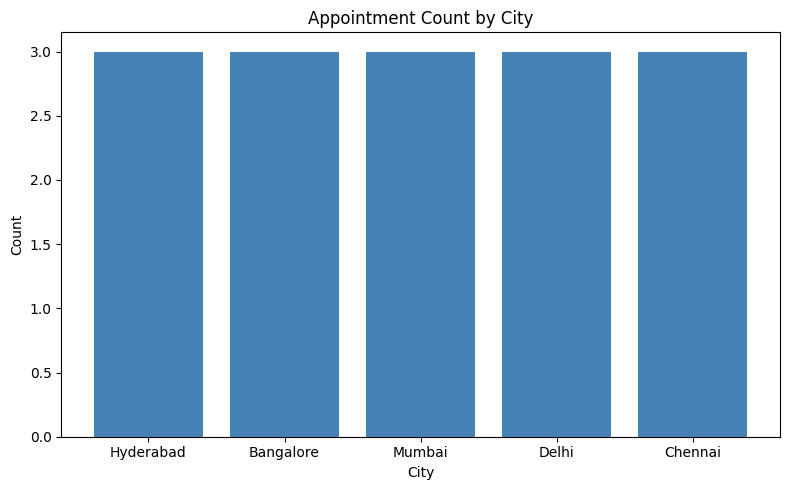

In [0]:
#2
city_count = df.groupBy('city').count().orderBy('count', ascending=False).toPandas()
plt.figure(figsize=(8, 5))
plt.bar(city_count['city'], city_count['count'], color='steelblue')
plt.title('Appointment Count by City')
plt.xlabel('City')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

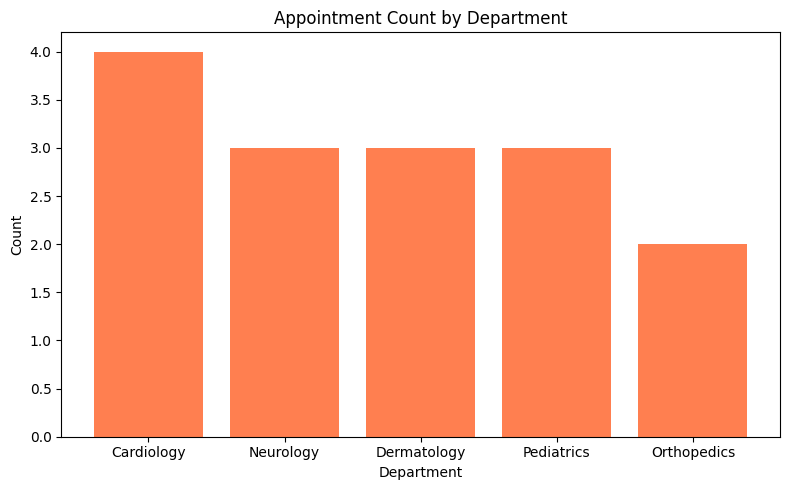

In [0]:
#3
dept_count = df.groupBy('department').count().orderBy('count', ascending=False).toPandas()
plt.figure(figsize=(8, 5))
plt.bar(dept_count['department'], dept_count['count'], color='coral')
plt.title('Appointment Count by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

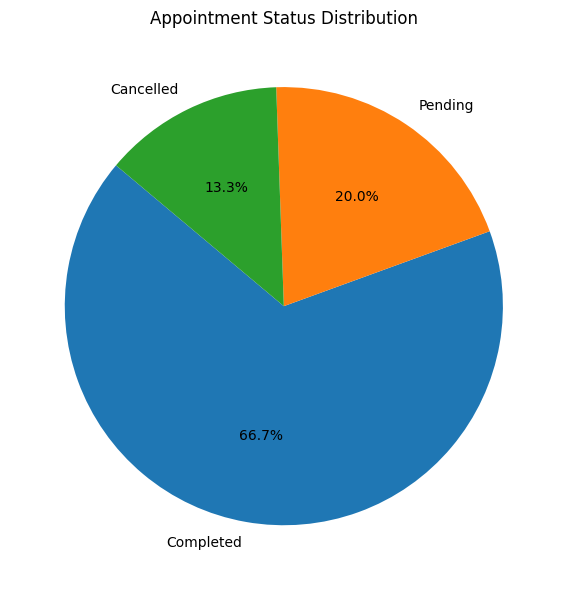

In [0]:
#4
status_count = df.groupBy('status').count().toPandas()
plt.figure(figsize=(6, 6))
plt.pie(status_count['count'], labels=status_count['status'], autopct='%1.1f%%', startangle=140)
plt.title('Appointment Status Distribution')
plt.tight_layout()
plt.show()

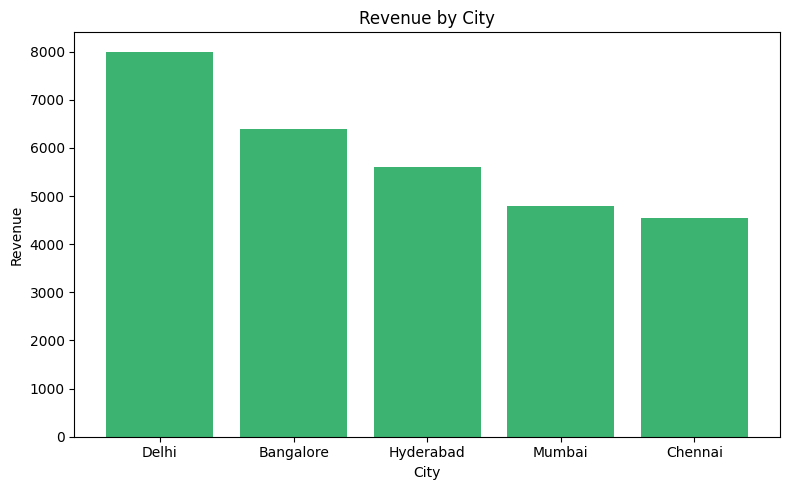

In [0]:
#5
from pyspark.sql.functions import sum as spark_sum
city_rev = df.groupBy('city').agg(spark_sum('consultation_fee').alias('revenue')).orderBy('revenue', ascending=False).toPandas()
plt.figure(figsize=(8, 5))
plt.bar(city_rev['city'], city_rev['revenue'], color='mediumseagreen')
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

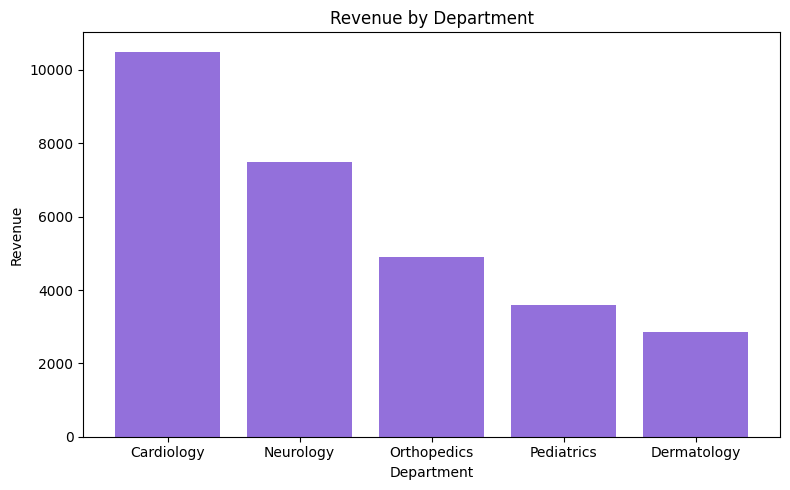

In [0]:
#6
dept_rev = df.groupBy('department').agg(spark_sum('consultation_fee').alias('revenue')).orderBy('revenue', ascending=False).toPandas()
plt.figure(figsize=(8, 5))
plt.bar(dept_rev['department'], dept_rev['revenue'], color='mediumpurple')
plt.title('Revenue by Department')
plt.xlabel('Department')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

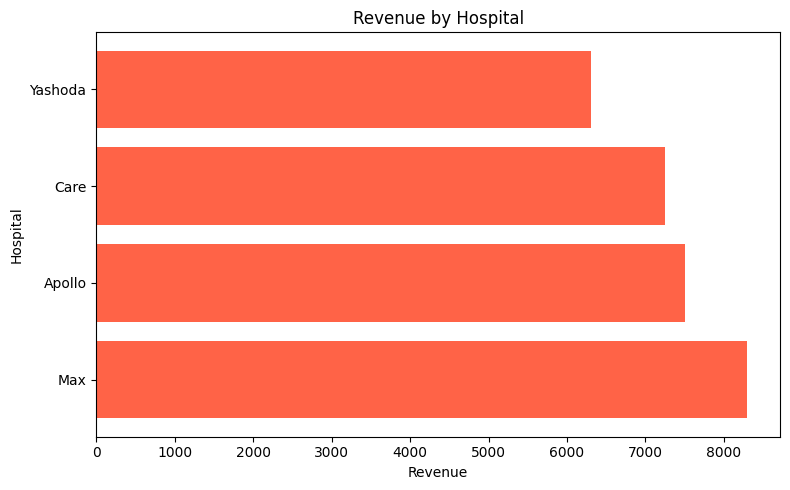

In [0]:
#7
hosp_rev = df.groupBy('hospital').agg(spark_sum('consultation_fee').alias('revenue')).orderBy('revenue', ascending=False).toPandas()
plt.figure(figsize=(8, 5))
plt.barh(hosp_rev['hospital'], hosp_rev['revenue'], color='tomato')
plt.title('Revenue by Hospital')
plt.xlabel('Revenue')
plt.ylabel('Hospital')
plt.tight_layout()
plt.show()

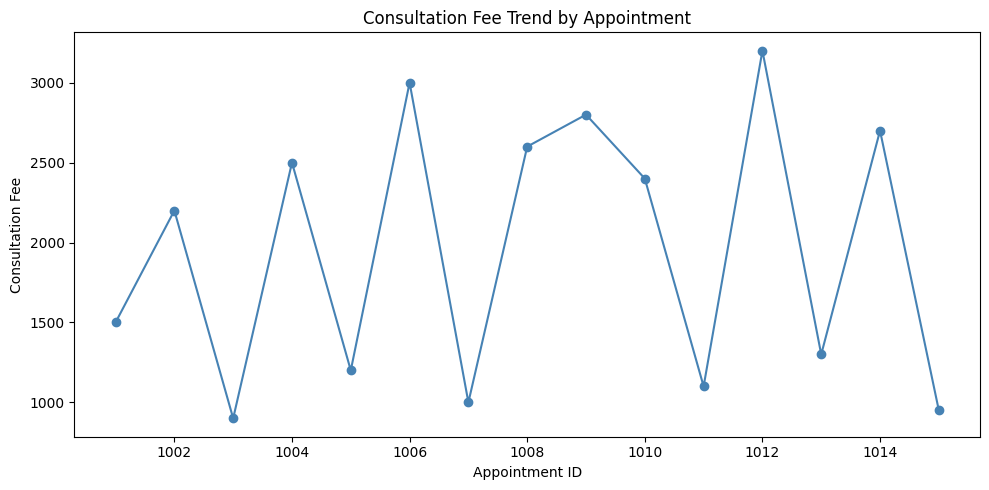

In [0]:
#8
fee_trend = df.orderBy('appointment_id').select('appointment_id', 'consultation_fee').toPandas()
plt.figure(figsize=(10, 5))
plt.plot(fee_trend['appointment_id'], fee_trend['consultation_fee'], marker='o', color='steelblue')
plt.title('Consultation Fee Trend by Appointment')
plt.xlabel('Appointment ID')
plt.ylabel('Consultation Fee')
plt.tight_layout()
plt.show()

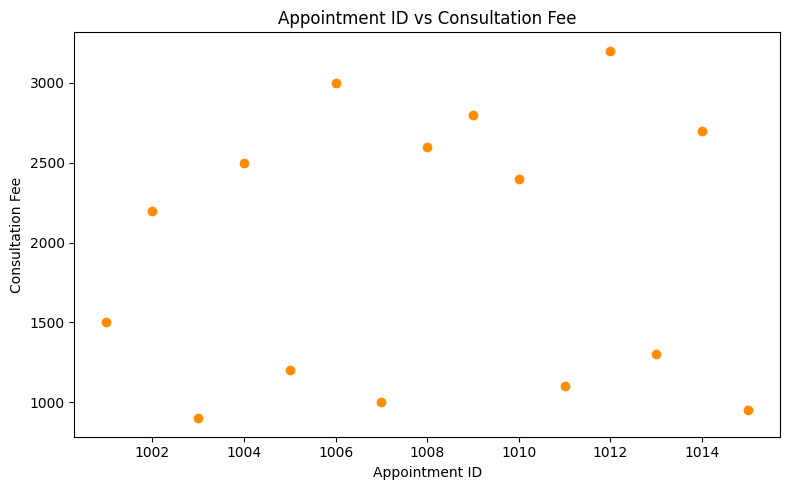

In [0]:
#9
scatter_df = df.select('appointment_id', 'consultation_fee').toPandas()
plt.figure(figsize=(8, 5))
plt.scatter(scatter_df['appointment_id'], scatter_df['consultation_fee'], color='darkorange')
plt.title('Appointment ID vs Consultation Fee')
plt.xlabel('Appointment ID')
plt.ylabel('Consultation Fee')
plt.tight_layout()
plt.show()

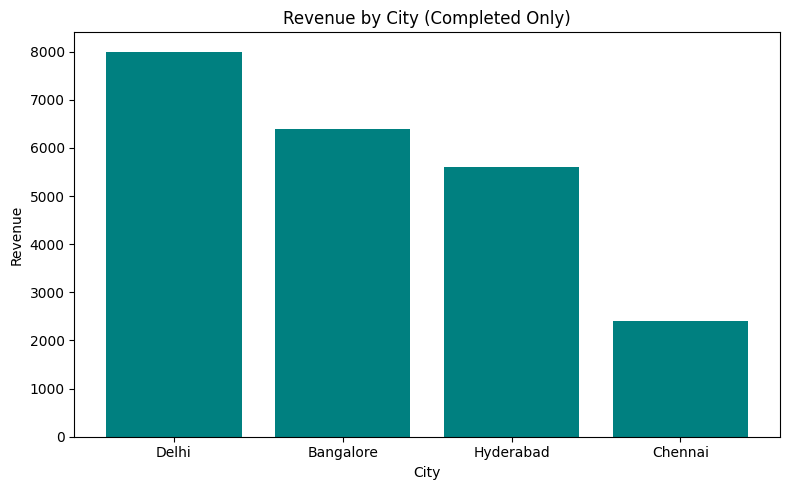

In [0]:
#10
completed_df = df.filter(col('status') == 'Completed')
completed_city = completed_df.groupBy('city').agg(spark_sum('consultation_fee').alias('revenue')).orderBy('revenue', ascending=False).toPandas()
plt.figure(figsize=(8, 5))
plt.bar(completed_city['city'], completed_city['revenue'], color='teal')
plt.title('Revenue by City (Completed Only)')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

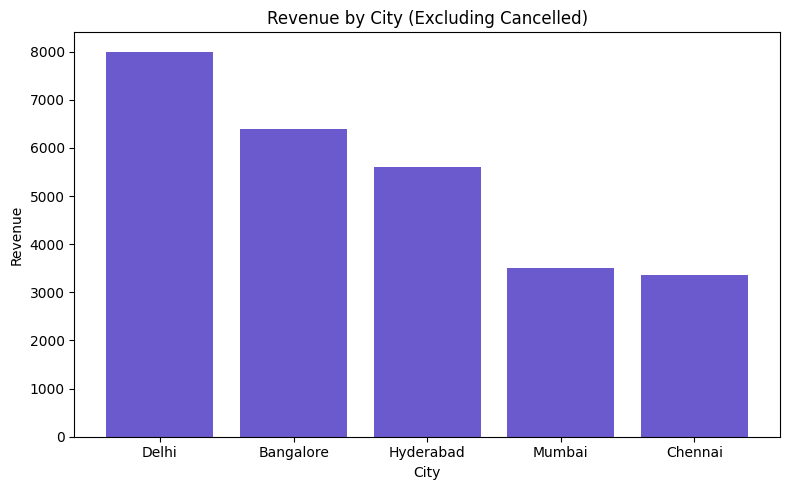

In [0]:
#11
no_cancelled = df.filter(col('status') != 'Cancelled')
no_cancelled_city = no_cancelled.groupBy('city').agg(spark_sum('consultation_fee').alias('revenue')).orderBy('revenue', ascending=False).toPandas()
plt.figure(figsize=(8, 5))
plt.bar(no_cancelled_city['city'], no_cancelled_city['revenue'], color='slateblue')
plt.title('Revenue by City (Excluding Cancelled)')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

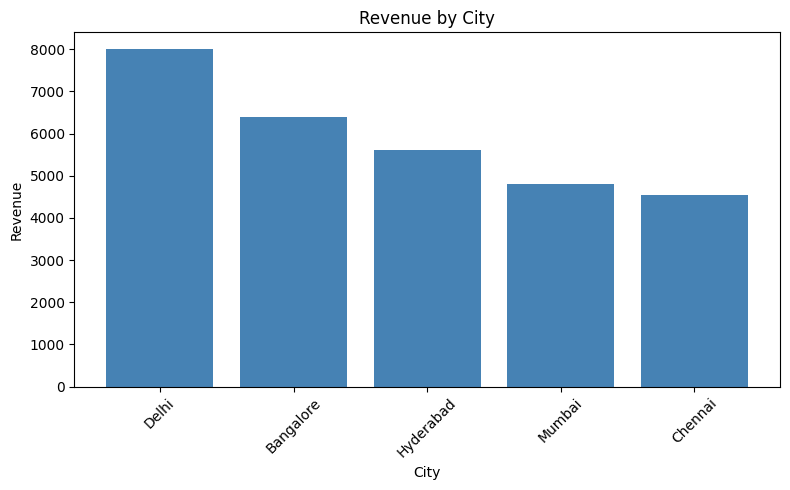

In [0]:
#12
city_rev2 = df.groupBy('city').agg(spark_sum('consultation_fee').alias('revenue')).orderBy('revenue', ascending=False).toPandas()
plt.figure(figsize=(8, 5))
plt.bar(city_rev2['city'], city_rev2['revenue'], color='steelblue')
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

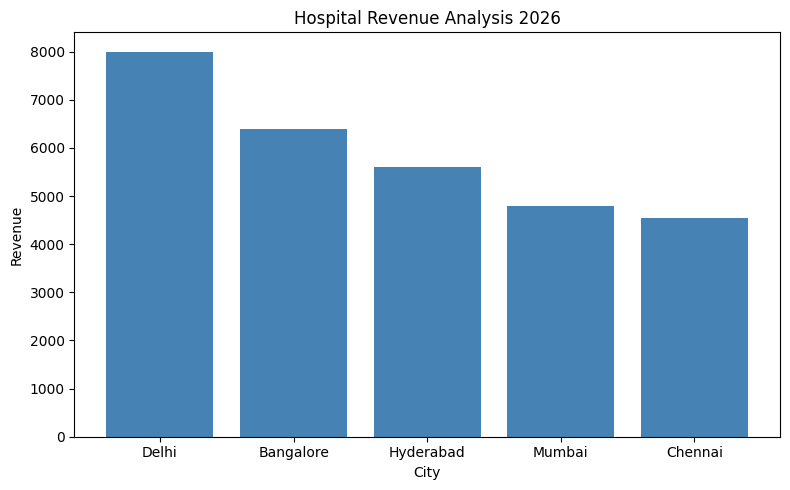

In [0]:
#13
plt.figure(figsize=(8, 5))
plt.bar(city_rev2['city'], city_rev2['revenue'], color='steelblue')
plt.title('Hospital Revenue Analysis 2026')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

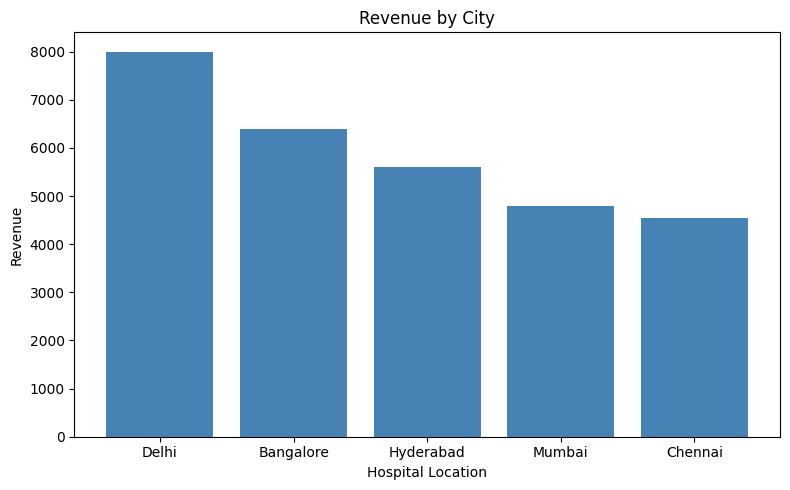

In [0]:
#14
plt.figure(figsize=(8, 5))
plt.bar(city_rev2['city'], city_rev2['revenue'], color='steelblue')
plt.title('Revenue by City')
plt.xlabel('Hospital Location')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

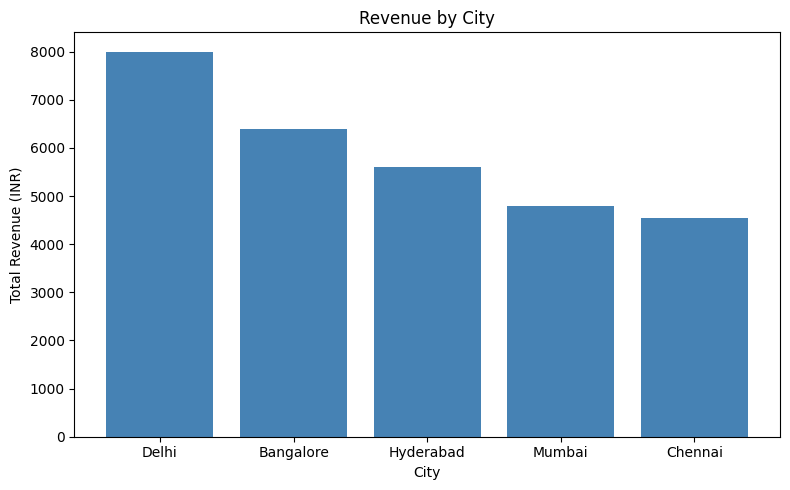

In [0]:
#15
plt.figure(figsize=(8, 5))
plt.bar(city_rev2['city'], city_rev2['revenue'], color='steelblue')
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue (INR)')
plt.tight_layout()
plt.show()

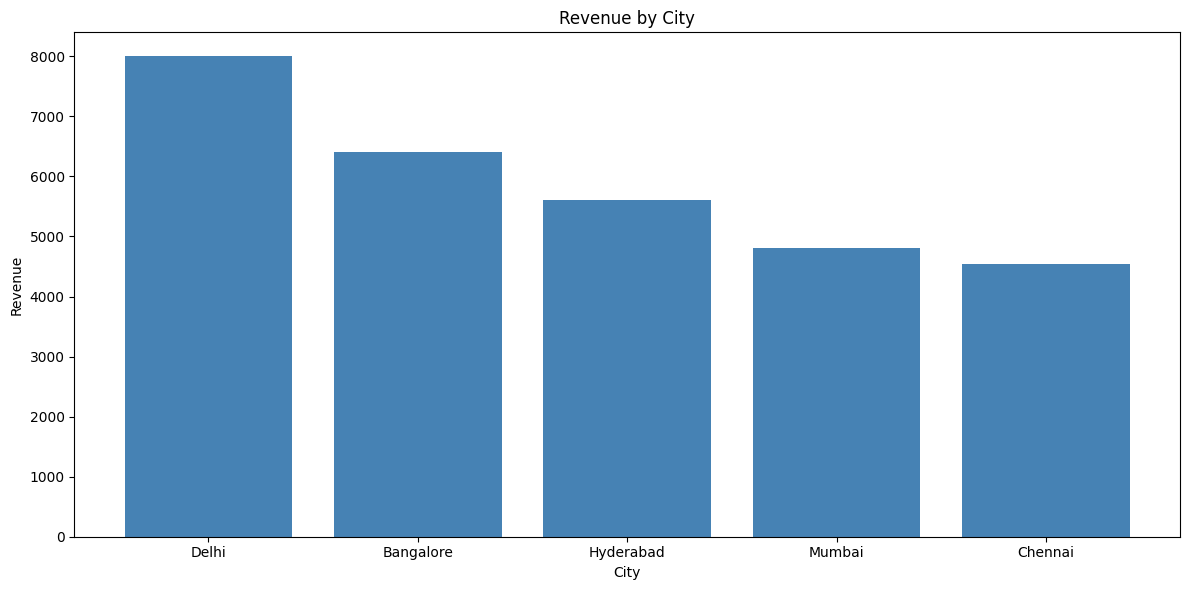

In [0]:
#16
plt.figure(figsize=(12, 6))
plt.bar(city_rev2['city'], city_rev2['revenue'], color='steelblue')
plt.title('Revenue by City')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

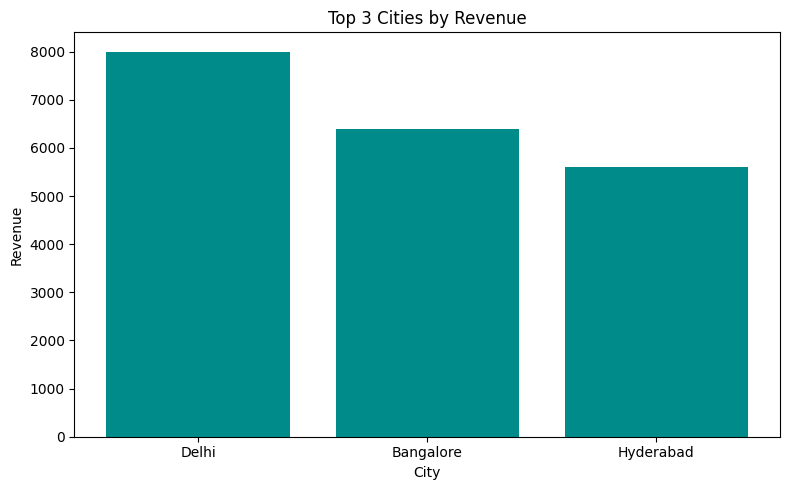

In [0]:
#17
top3_city = city_rev2.head(3)
plt.figure(figsize=(8, 5))
plt.bar(top3_city['city'], top3_city['revenue'], color='darkcyan')
plt.title('Top 3 Cities by Revenue')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

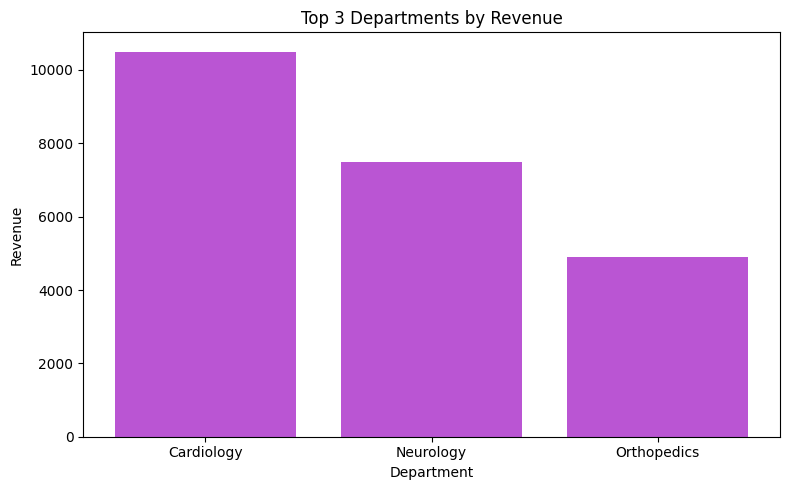

In [0]:
#18
top3_dept = dept_rev.head(3)
plt.figure(figsize=(8, 5))
plt.bar(top3_dept['department'], top3_dept['revenue'], color='mediumorchid')
plt.title('Top 3 Departments by Revenue')
plt.xlabel('Department')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

In [0]:
#19
lowest_hosp = hosp_rev.tail(1)
print('Lowest Revenue Hospital:')
print(lowest_hosp[['hospital', 'revenue']].to_string(index=False))

Lowest Revenue Hospital:
hospital  revenue
 Yashoda     6300


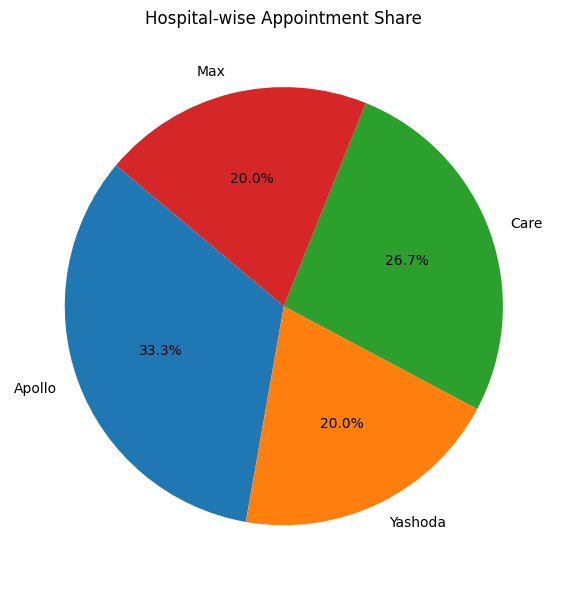

In [0]:
#20
hosp_count = df.groupBy('hospital').count().toPandas()
plt.figure(figsize=(6, 6))
plt.pie(hosp_count['count'], labels=hosp_count['hospital'], autopct='%1.1f%%', startangle=140)
plt.title('Hospital-wise Appointment Share')
plt.tight_layout()
plt.show()

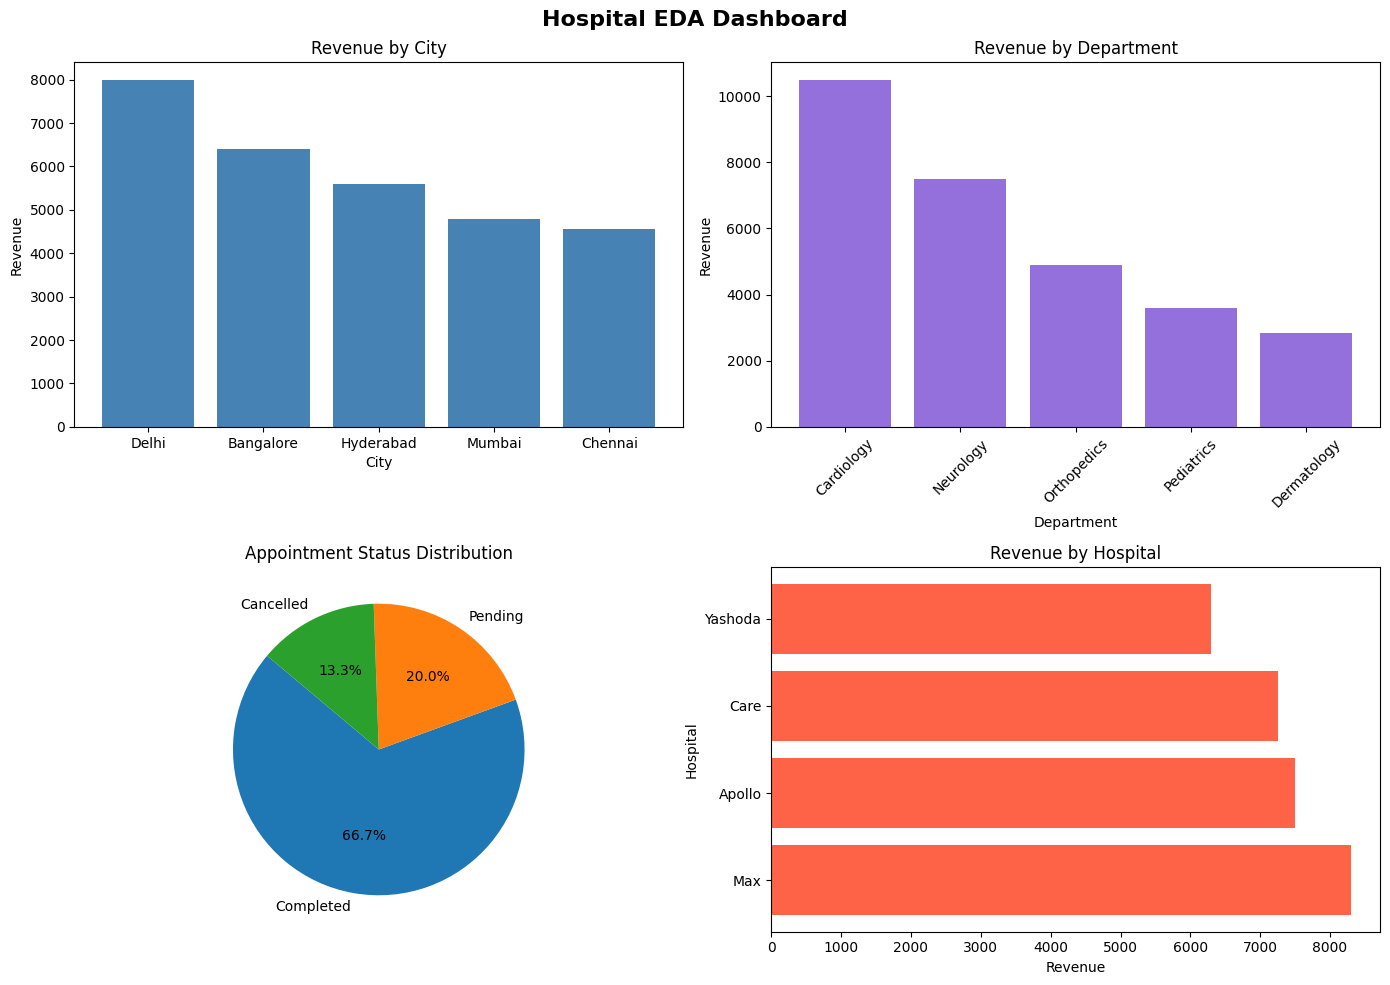

In [0]:
#21
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(city_rev2['city'], city_rev2['revenue'], color='steelblue')
axes[0, 0].set_title('Revenue by City')
axes[0, 0].set_xlabel('City')
axes[0, 0].set_ylabel('Revenue')

axes[0, 1].bar(dept_rev['department'], dept_rev['revenue'], color='mediumpurple')
axes[0, 1].set_title('Revenue by Department')
axes[0, 1].set_xlabel('Department')
axes[0, 1].set_ylabel('Revenue')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].pie(status_count['count'], labels=status_count['status'], autopct='%1.1f%%', startangle=140)
axes[1, 0].set_title('Appointment Status Distribution')

axes[1, 1].barh(hosp_rev['hospital'], hosp_rev['revenue'], color='tomato')
axes[1, 1].set_title('Revenue by Hospital')
axes[1, 1].set_xlabel('Revenue')
axes[1, 1].set_ylabel('Hospital')

plt.suptitle('Hospital EDA Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()